Summary results:
topology            policy  avg_impact_share_tier1  std_impact_share_tier1  avg_n_impacted_tier1  severe_disruption_prob  avg_visibility_size  avg_selected_backups  avg_n_disrupted_nodes  p90_impact_share_tier1
   dense   visibility_only                0.333000                0.268493                 1.998                   0.398                  6.0                   0.0                  1.718                0.666667
   dense            hybrid                0.357333                0.288736                 2.144                   0.412                  3.0                   1.0                  1.672                0.833333
   dense       backup_only                0.362333                0.311033                 2.174                   0.384                  0.0                   3.0                  1.814                0.666667
   dense     random_backup                0.365667                0.330329                 2.194                   0.420                  0

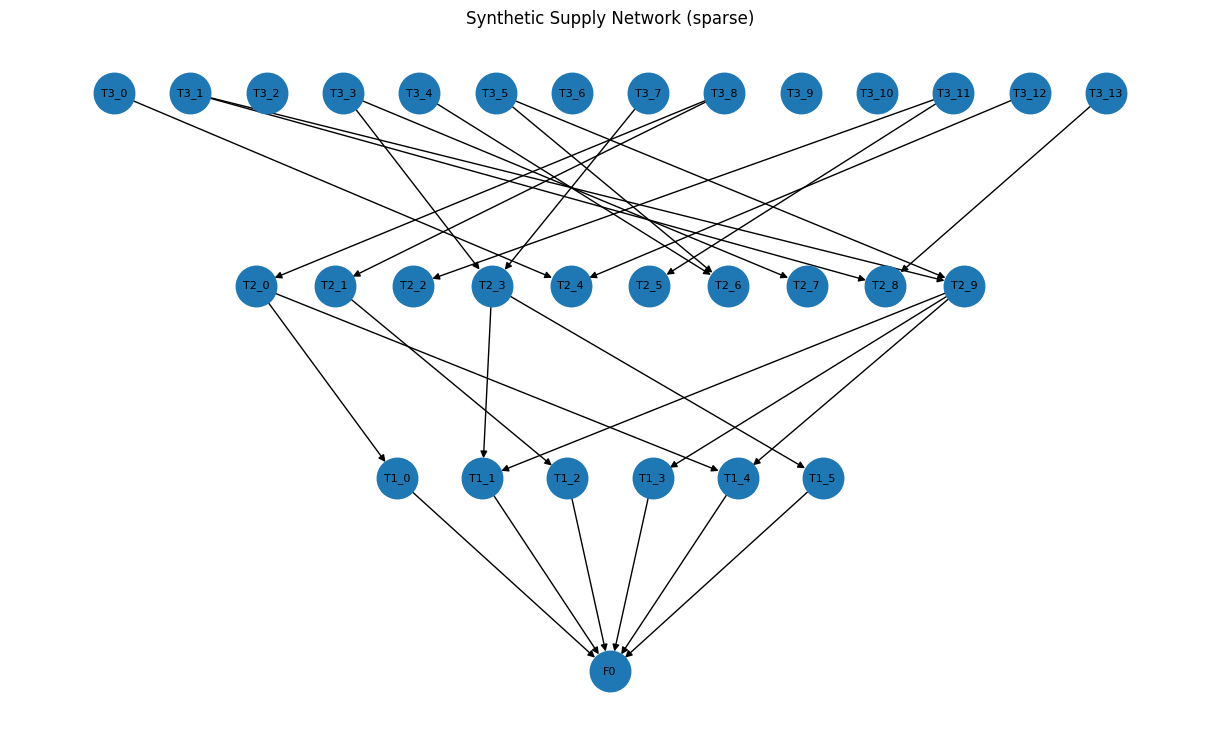

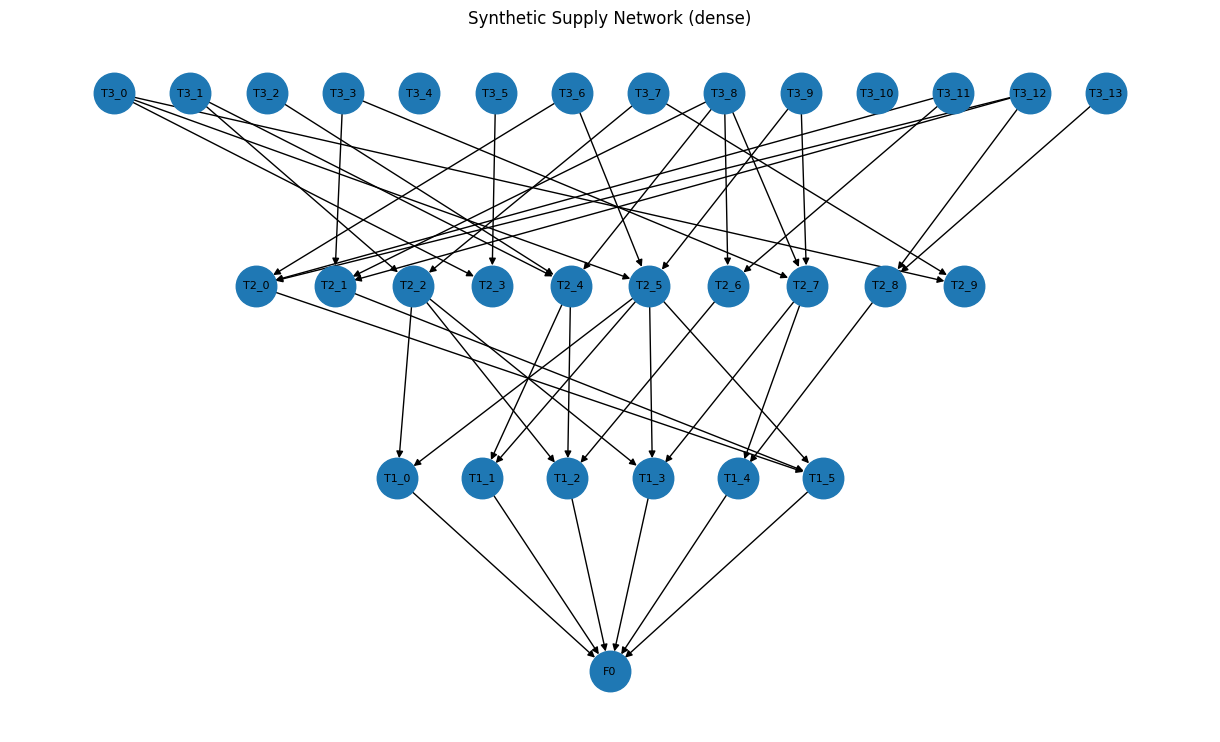

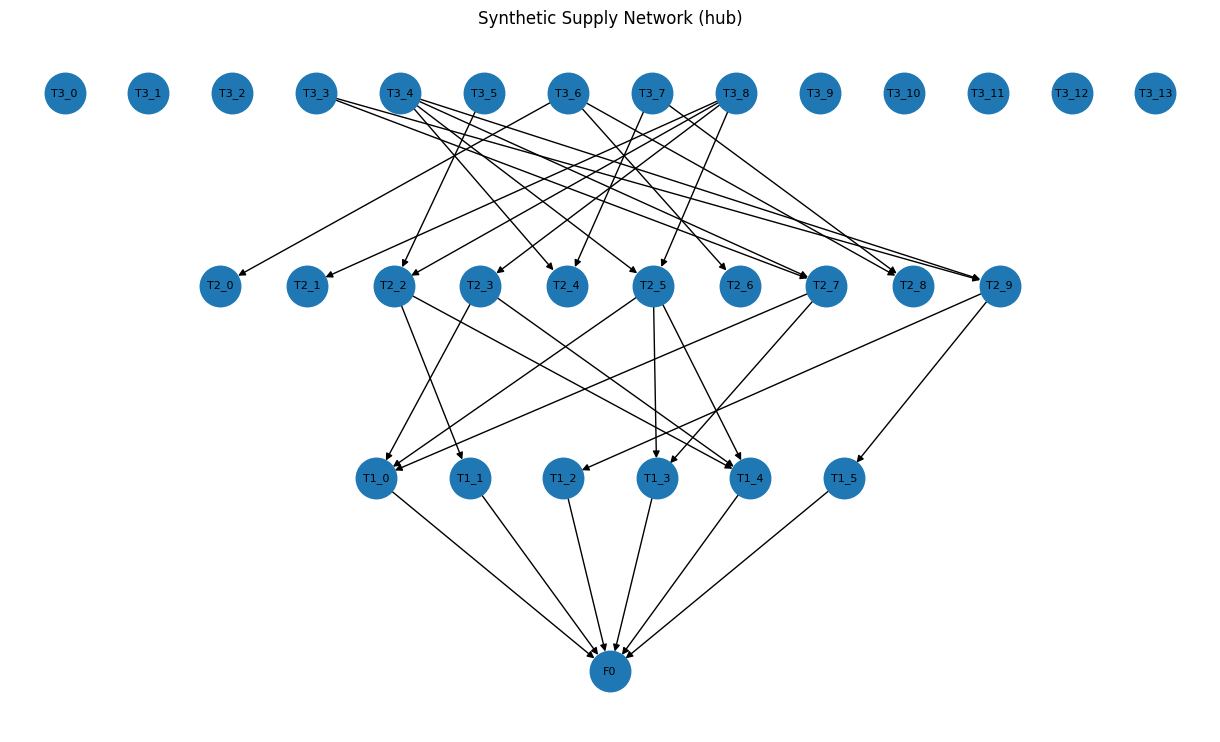

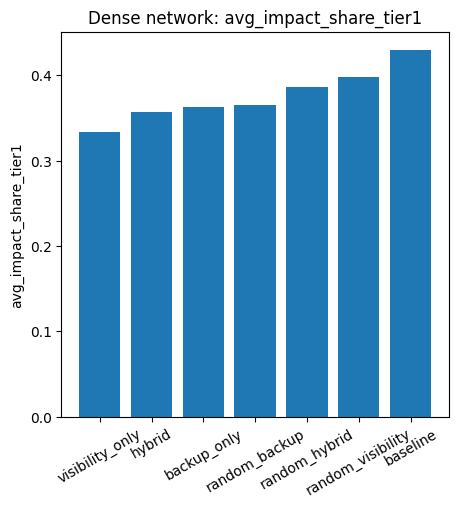

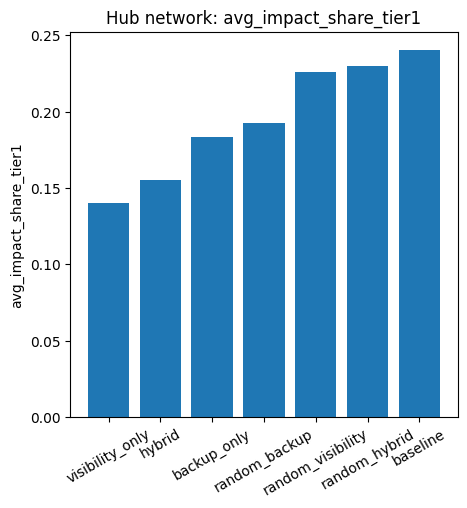

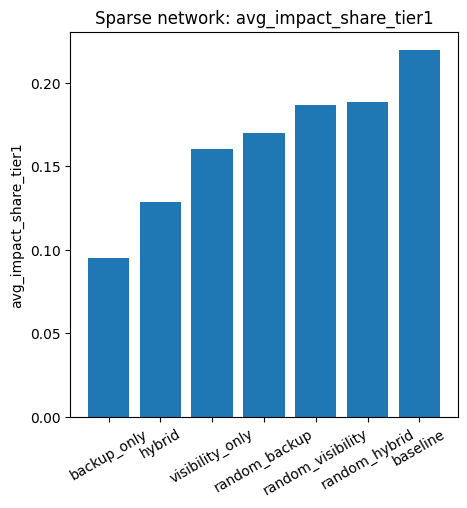

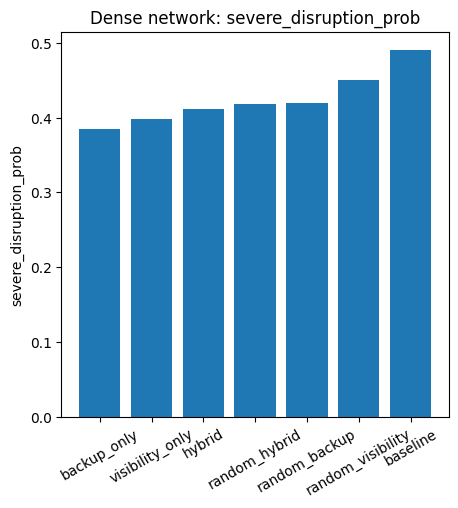

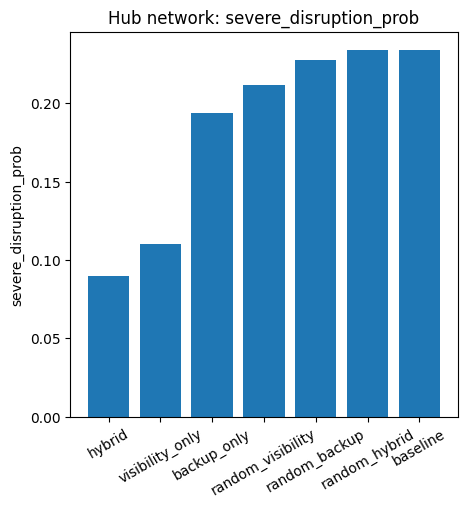

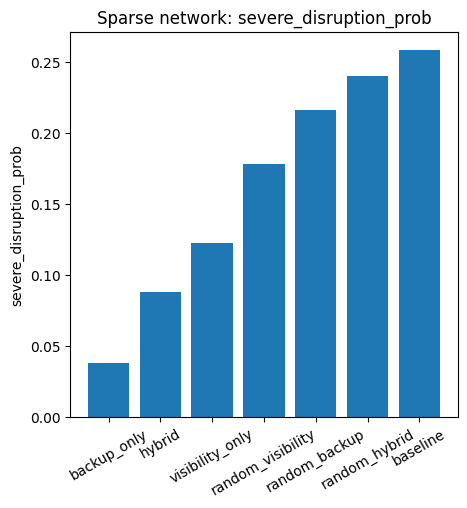

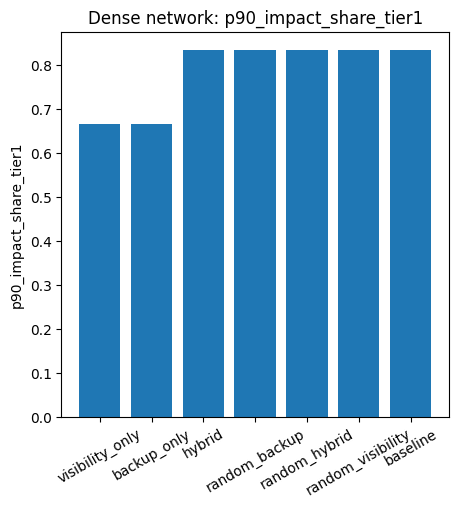

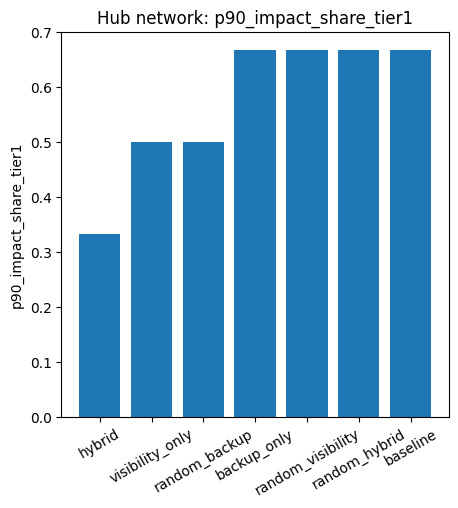

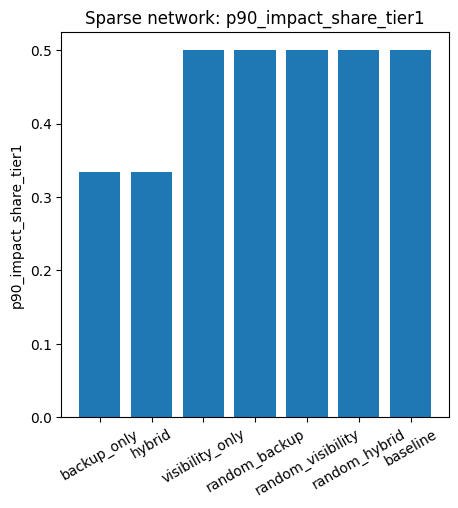

/tmp/ipykernel_16805/1391487619.py:711: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=policies)


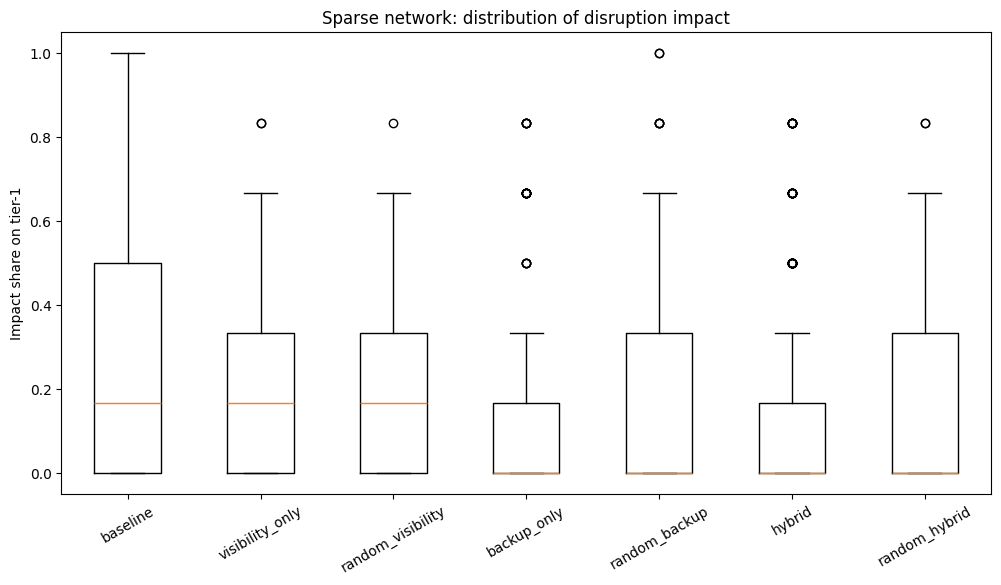

/tmp/ipykernel_16805/1391487619.py:711: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=policies)


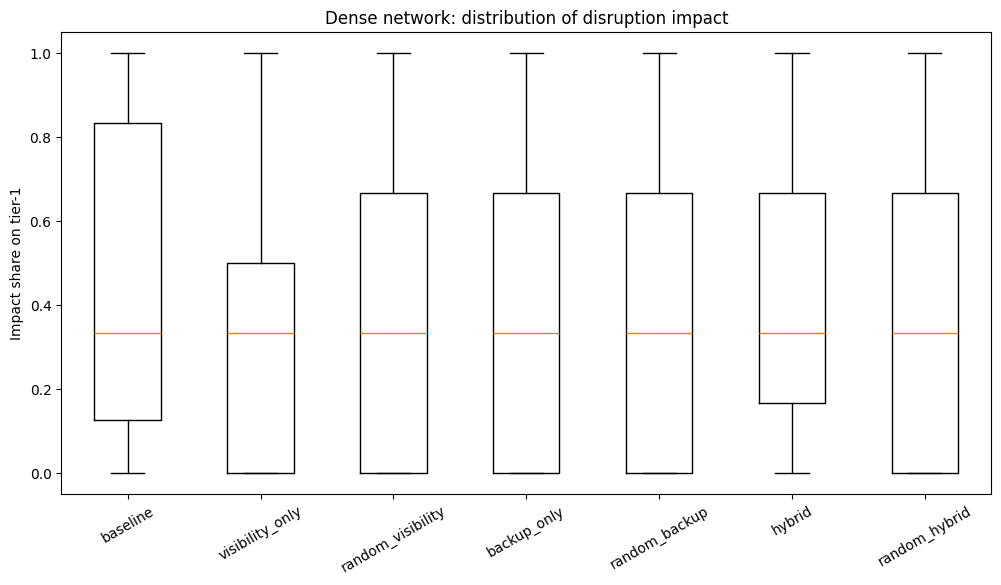

/tmp/ipykernel_16805/1391487619.py:711: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=policies)


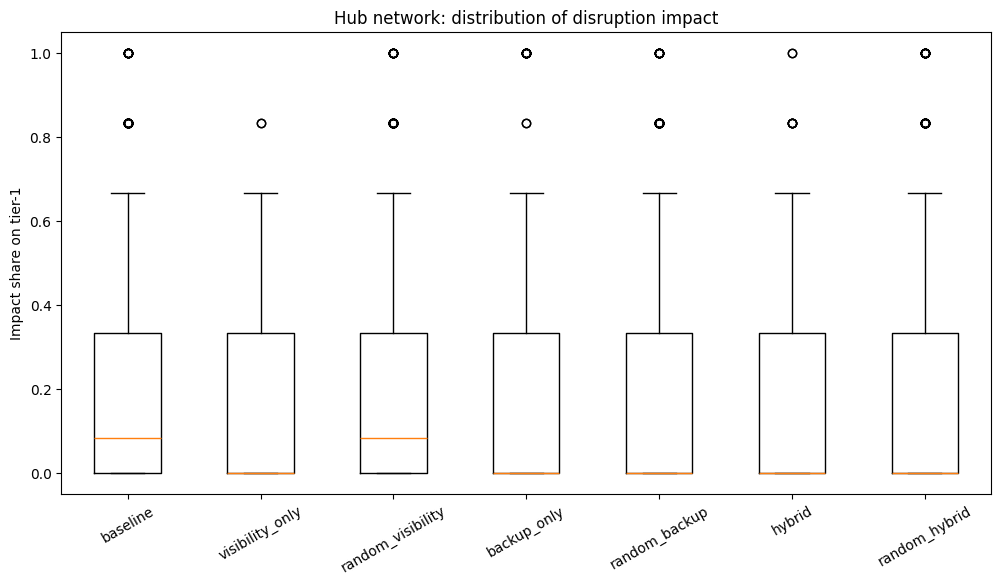

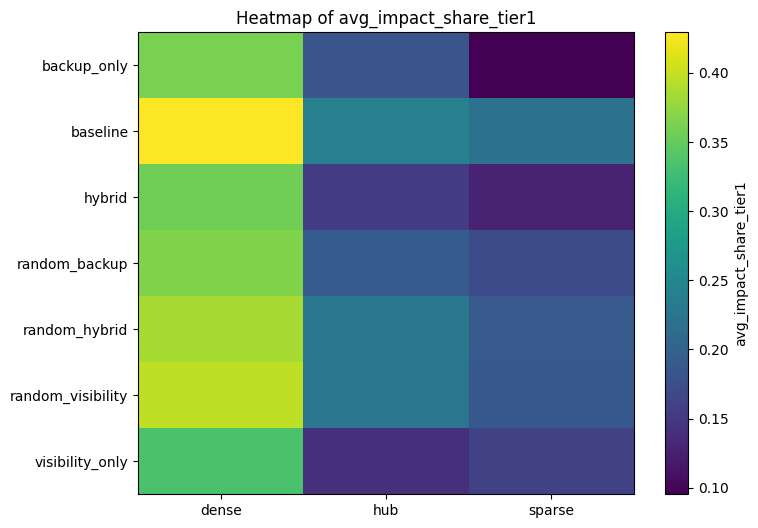

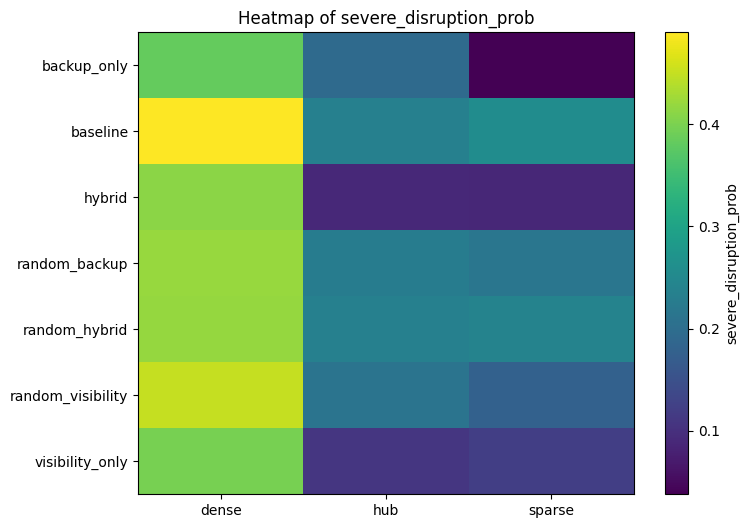

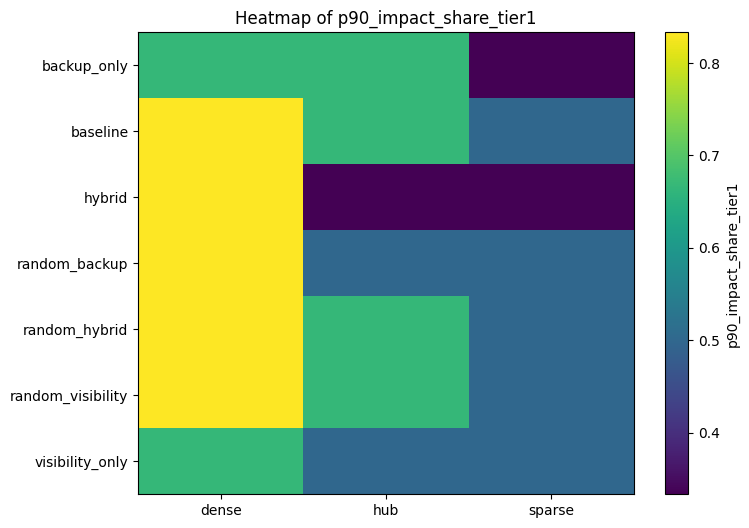


First rows of scenario-level results:


,topology,scenario_id,policy,impact_share_tier1,n_impacted_tier1,n_disrupted_nodes,visibility_size,selected_backups,severe_disruption
0,sparse,0,baseline,0.000000,0,3,0,0,0
1,sparse,1,baseline,0.333333,2,1,0,0,0
2,sparse,2,baseline,0.000000,0,2,0,0,0
3,sparse,3,baseline,0.000000,0,2,0,0,0
4,sparse,4,baseline,0.666667,4,3,0,0,1
5,sparse,5,baseline,0.333333,2,1,0,0,0
6,sparse,6,baseline,0.000000,0,1,0,0,0
7,sparse,7,baseline,0.000000,0,0,0,0,0
8,sparse,8,baseline,0.500000,3,3,0,0,1
9,sparse,9,baseline,0.500000,3,2,0,0,1


In [ ]:
import random
from dataclasses import dataclass
from typing import Dict, List, Set, Tuple, Optional

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt


# ============================================================
# 1. PARAMETERS
# ============================================================

SEED = 42

@dataclass
class ModelParams:
    # Network size
    n_tier1: int = 6
    n_tier2: int = 10
    n_tier3: int = 14

    # Disruption probabilities by tier
    p_tier: Dict[int, float] = None

    # Budget settings
    total_budget: int = 6
    visibility_cost_per_node: int = 1
    backup_cost_per_tier1: int = 2

    # Hybrid split
    hybrid_visibility_share: float = 0.5

    # Early-warning mitigation effectiveness for monitored disrupted nodes
    mitigation_success: float = 0.6

    # Monte Carlo
    n_scenarios: int = 500

    # Severe disruption threshold
    severe_threshold: float = 0.5

    def __post_init__(self):
        if self.p_tier is None:
            self.p_tier = {1: 0.03, 2: 0.05, 3: 0.07}


params = ModelParams()


# ============================================================
# 2. NETWORK GENERATION
# ============================================================

def generate_supply_network(params: ModelParams, topology: str = "sparse", seed: int = 42):
    """
    Creates a layered supply network:
    tier 3 -> tier 2 -> tier 1 -> focal firm
    Edges point from supplier to customer.

    topology:
        - sparse
        - dense
        - hub
    """
    rng = random.Random(seed)
    G = nx.DiGraph()

    focal = "F0"
    G.add_node(focal, tier=0, kind="focal")

    tiers = {
        1: [f"T1_{i}" for i in range(params.n_tier1)],
        2: [f"T2_{i}" for i in range(params.n_tier2)],
        3: [f"T3_{i}" for i in range(params.n_tier3)],
    }

    for tier, nodes in tiers.items():
        for node in nodes:
            G.add_node(node, tier=tier, kind="supplier")

    # Tier-1 suppliers connect to focal firm
    for t1 in tiers[1]:
        G.add_edge(t1, focal)

    # Topology-specific parent selection
    if topology == "sparse":
        t1_parent_range = (1, 2)
        t2_parent_range = (1, 2)
        hub_share_t2 = 0.0
        hub_share_t3 = 0.0
    elif topology == "dense":
        t1_parent_range = (2, 3)
        t2_parent_range = (2, 3)
        hub_share_t2 = 0.0
        hub_share_t3 = 0.0
    elif topology == "hub":
        t1_parent_range = (1, 3)
        t2_parent_range = (1, 2)
        hub_share_t2 = 0.25
        hub_share_t3 = 0.20
    else:
        raise ValueError("topology must be one of: 'sparse', 'dense', 'hub'")

    # Build Tier-2 -> Tier-1
    add_edges_layer(
        G=G,
        upstream_nodes=tiers[2],
        downstream_nodes=tiers[1],
        parent_range=t1_parent_range,
        rng=rng,
        hub_share=hub_share_t2
    )

    # Build Tier-3 -> Tier-2
    add_edges_layer(
        G=G,
        upstream_nodes=tiers[3],
        downstream_nodes=tiers[2],
        parent_range=t2_parent_range,
        rng=rng,
        hub_share=hub_share_t3
    )

    return G, tiers


def add_edges_layer(
    G: nx.DiGraph,
    upstream_nodes: List[str],
    downstream_nodes: List[str],
    parent_range: Tuple[int, int],
    rng: random.Random,
    hub_share: float = 0.0
):
    """
    Adds upstream -> downstream edges.
    If hub_share > 0, some upstream nodes are designated as hubs and selected more often.
    """
    min_k, max_k = parent_range
    max_k = min(max_k, len(upstream_nodes))
    min_k = min(min_k, max_k)

    hubs = set()
    if hub_share > 0:
        n_hubs = max(1, int(round(len(upstream_nodes) * hub_share)))
        hubs = set(rng.sample(upstream_nodes, n_hubs))

    for d in downstream_nodes:
        k = rng.randint(min_k, max_k)

        if not hubs:
            parents = rng.sample(upstream_nodes, k)
        else:
            weighted_pool = []
            for u in upstream_nodes:
                weighted_pool.append(u)
                if u in hubs:
                    weighted_pool.extend([u, u, u])  # bias toward hubs

            # sample unique parents from weighted pool
            parents = []
            seen = set()
            attempts = 0
            while len(parents) < k and attempts < 1000:
                candidate = rng.choice(weighted_pool)
                if candidate not in seen:
                    parents.append(candidate)
                    seen.add(candidate)
                attempts += 1

            if len(parents) < k:
                remaining = [u for u in upstream_nodes if u not in seen]
                need = k - len(parents)
                parents.extend(rng.sample(remaining, need))

        for u in parents:
            G.add_edge(u, d)


# ============================================================
# 3. HELPERS
# ============================================================

def get_ancestors_cache(G: nx.DiGraph, tier1_nodes: List[str]) -> Dict[str, Set[str]]:
    return {t1: nx.ancestors(G, t1) for t1 in tier1_nodes}


def disrupted_nodes_in_scenario(G: nx.DiGraph, p_tier: Dict[int, float], rng: random.Random) -> Set[str]:
    disrupted = set()
    for node in G.nodes:
        if node == "F0":
            continue
        tier = G.nodes[node]["tier"]
        if rng.random() < p_tier[tier]:
            disrupted.add(node)
    return disrupted


def supplier_failed(
    G: nx.DiGraph,
    tier1_supplier: str,
    disrupted: Set[str],
    monitored_nodes: Set[str],
    mitigation_success: float,
    rng: random.Random,
    ancestors_cache: Optional[Dict[str, Set[str]]] = None
) -> bool:
    """
    A tier-1 supplier fails if:
    - it is disrupted itself, or
    - any upstream ancestor is disrupted,
    unless a disrupted node is monitored and mitigation succeeds.
    """
    if ancestors_cache is None:
        relevant_nodes = nx.ancestors(G, tier1_supplier) | {tier1_supplier}
    else:
        relevant_nodes = ancestors_cache[tier1_supplier] | {tier1_supplier}

    disrupted_relevant = relevant_nodes & disrupted

    if not disrupted_relevant:
        return False

    for node in disrupted_relevant:
        if node in monitored_nodes:
            if rng.random() < mitigation_success:
                continue
        return True

    return False


def downstream_tier1_coverage(G: nx.DiGraph, node: str) -> int:
    descendants = nx.descendants(G, node)
    return sum(1 for d in descendants if G.nodes[d]["tier"] == 1)


def compute_node_scores(G: nx.DiGraph, tiers: Dict[int, List[str]]) -> Dict[str, float]:
    """
    Score upstream nodes using their influence over tier-1 exposure.
    """
    candidates = tiers[2] + tiers[3]
    coverage = {node: downstream_tier1_coverage(G, node) for node in candidates}

    scores = {}
    for node in candidates:
        scores[node] = (
            3.0 * coverage[node] +
            1.0 * G.out_degree(node) +
            0.25 * nx.degree_centrality(G)[node]
        )
    return scores


def choose_visibility_nodes_targeted(
    G: nx.DiGraph,
    tiers: Dict[int, List[str]],
    budget: int,
    cost_per_node: int
) -> Tuple[Set[str], Dict[str, float]]:
    n_pick = budget // cost_per_node
    candidates = tiers[2] + tiers[3]
    scores = compute_node_scores(G, tiers)

    ranked = sorted(candidates, key=lambda n: scores[n], reverse=True)
    selected = set(ranked[:n_pick])
    return selected, scores


def choose_visibility_nodes_random(
    G: nx.DiGraph,
    tiers: Dict[int, List[str]],
    budget: int,
    cost_per_node: int,
    rng: random.Random
) -> Tuple[Set[str], Dict[str, float]]:
    n_pick = budget // cost_per_node
    candidates = tiers[2] + tiers[3]
    n_pick = min(n_pick, len(candidates))
    selected = set(rng.sample(candidates, n_pick))
    dummy_scores = {node: 0.0 for node in candidates}
    return selected, dummy_scores


def choose_backup_assignments_targeted(
    G: nx.DiGraph,
    tiers: Dict[int, List[str]],
    budget: int,
    cost_per_backup: int,
    visible_nodes: Set[str]
) -> Tuple[Dict[str, str], Dict[str, float]]:
    """
    Unique backup assignment:
    one backup supplier can serve at most one primary.
    Primary tier-1 suppliers are chosen based on visible risk.
    Backup partner is chosen to minimize overlap in upstream ancestry.
    """
    n_protected = budget // cost_per_backup
    tier1_nodes = tiers[1]
    n_protected = min(n_protected, len(tier1_nodes) // 2)  # need unique backup nodes

    ancestors_cache = get_ancestors_cache(G, tier1_nodes)

    # visible risk score
    scores = {}
    for t1 in tier1_nodes:
        visible_ancestors = [a for a in ancestors_cache[t1] if a in visible_nodes]
        total_ancestors = len(ancestors_cache[t1])
        scores[t1] = 1.0 + 1.5 * len(visible_ancestors) + 0.25 * total_ancestors

    primaries_ranked = sorted(tier1_nodes, key=lambda x: scores[x], reverse=True)

    backups = {}
    used_nodes = set()

    for primary in primaries_ranked:
        if len(backups) >= n_protected:
            break
        if primary in used_nodes:
            continue

        primary_set = ancestors_cache[primary] | {primary}

        best_candidate = None
        best_tuple = None

        for candidate in tier1_nodes:
            if candidate == primary or candidate in used_nodes:
                continue

            candidate_set = ancestors_cache[candidate] | {candidate}
            overlap = len(primary_set & candidate_set)
            candidate_risk = scores[candidate]
            candidate_coverage = len(candidate_set)

            ranking_tuple = (overlap, candidate_risk, candidate_coverage)
            # lower overlap better; lower backup risk better; lower shared exposure footprint often better
            if best_tuple is None or ranking_tuple < best_tuple:
                best_tuple = ranking_tuple
                best_candidate = candidate

        if best_candidate is not None:
            backups[primary] = best_candidate
            used_nodes.add(primary)
            used_nodes.add(best_candidate)

    return backups, scores


def choose_backup_assignments_random(
    G: nx.DiGraph,
    tiers: Dict[int, List[str]],
    budget: int,
    cost_per_backup: int,
    rng: random.Random
) -> Tuple[Dict[str, str], Dict[str, float]]:
    """
    Random unique primary-backup pairs.
    """
    tier1_nodes = list(tiers[1])
    n_pairs = min(budget // cost_per_backup, len(tier1_nodes) // 2)

    shuffled = tier1_nodes[:]
    rng.shuffle(shuffled)

    backups = {}
    for i in range(n_pairs):
        primary = shuffled[2 * i]
        backup = shuffled[2 * i + 1]
        backups[primary] = backup

    dummy_scores = {node: 0.0 for node in tier1_nodes}
    return backups, dummy_scores


# ============================================================
# 4. POLICY EVALUATION
# ============================================================

def evaluate_policy(
    G: nx.DiGraph,
    tiers: Dict[int, List[str]],
    topology: str,
    policy_name: str,
    monitored_nodes: Set[str],
    backups: Dict[str, str],
    params: ModelParams,
    seed: int
) -> pd.DataFrame:

    rng = random.Random(seed)
    tier1_nodes = tiers[1]
    ancestors_cache = get_ancestors_cache(G, tier1_nodes)

    rows = []

    for scenario_id in range(params.n_scenarios):
        disrupted = disrupted_nodes_in_scenario(G, params.p_tier, rng)

        primary_failure = {}
        for t1 in tier1_nodes:
            primary_failure[t1] = supplier_failed(
                G=G,
                tier1_supplier=t1,
                disrupted=disrupted,
                monitored_nodes=monitored_nodes,
                mitigation_success=params.mitigation_success,
                rng=rng,
                ancestors_cache=ancestors_cache
            )

        impacted_tier1 = 0

        for t1 in tier1_nodes:
            if not primary_failure[t1]:
                continue

            if t1 in backups:
                backup = backups[t1]
                backup_failed = supplier_failed(
                    G=G,
                    tier1_supplier=backup,
                    disrupted=disrupted,
                    monitored_nodes=monitored_nodes,
                    mitigation_success=params.mitigation_success,
                    rng=rng,
                    ancestors_cache=ancestors_cache
                )
                if not backup_failed:
                    continue

            impacted_tier1 += 1

        impact_share = impacted_tier1 / len(tier1_nodes)

        rows.append({
            "topology": topology,
            "scenario_id": scenario_id,
            "policy": policy_name,
            "impact_share_tier1": impact_share,
            "n_impacted_tier1": impacted_tier1,
            "n_disrupted_nodes": len(disrupted),
            "visibility_size": len(monitored_nodes),
            "selected_backups": len(backups),
            "severe_disruption": int(impact_share >= params.severe_threshold),
        })

    return pd.DataFrame(rows)


# ============================================================
# 5. EXPERIMENT RUNNER
# ============================================================

def run_experiment_for_topology(params: ModelParams, topology: str, seed: int = 42):
    G, tiers = generate_supply_network(params, topology=topology, seed=seed)
    results = []

    # Baseline
    results.append(evaluate_policy(
        G, tiers, topology, "baseline",
        monitored_nodes=set(),
        backups={},
        params=params,
        seed=seed + 1
    ))

    # Targeted visibility
    vis_nodes_targeted, vis_scores = choose_visibility_nodes_targeted(
        G, tiers,
        budget=params.total_budget,
        cost_per_node=params.visibility_cost_per_node
    )
    results.append(evaluate_policy(
        G, tiers, topology, "visibility_only",
        monitored_nodes=vis_nodes_targeted,
        backups={},
        params=params,
        seed=seed + 2
    ))

    # Random visibility
    rng_vis = random.Random(seed + 100)
    vis_nodes_random, _ = choose_visibility_nodes_random(
        G, tiers,
        budget=params.total_budget,
        cost_per_node=params.visibility_cost_per_node,
        rng=rng_vis
    )
    results.append(evaluate_policy(
        G, tiers, topology, "random_visibility",
        monitored_nodes=vis_nodes_random,
        backups={},
        params=params,
        seed=seed + 3
    ))

    # Targeted backup
    backups_targeted, backup_scores = choose_backup_assignments_targeted(
        G, tiers,
        budget=params.total_budget,
        cost_per_backup=params.backup_cost_per_tier1,
        visible_nodes=set()
    )
    results.append(evaluate_policy(
        G, tiers, topology, "backup_only",
        monitored_nodes=set(),
        backups=backups_targeted,
        params=params,
        seed=seed + 4
    ))

    # Random backup
    rng_backup = random.Random(seed + 200)
    backups_random, _ = choose_backup_assignments_random(
        G, tiers,
        budget=params.total_budget,
        cost_per_backup=params.backup_cost_per_tier1,
        rng=rng_backup
    )
    results.append(evaluate_policy(
        G, tiers, topology, "random_backup",
        monitored_nodes=set(),
        backups=backups_random,
        params=params,
        seed=seed + 5
    ))

    # Targeted hybrid
    vis_budget = int(round(params.total_budget * params.hybrid_visibility_share))
    backup_budget = params.total_budget - vis_budget

    hybrid_vis_nodes, hybrid_vis_scores = choose_visibility_nodes_targeted(
        G, tiers,
        budget=vis_budget,
        cost_per_node=params.visibility_cost_per_node
    )
    hybrid_backups, hybrid_backup_scores = choose_backup_assignments_targeted(
        G, tiers,
        budget=backup_budget,
        cost_per_backup=params.backup_cost_per_tier1,
        visible_nodes=hybrid_vis_nodes
    )
    results.append(evaluate_policy(
        G, tiers, topology, "hybrid",
        monitored_nodes=hybrid_vis_nodes,
        backups=hybrid_backups,
        params=params,
        seed=seed + 6
    ))

    # Random hybrid
    rng_hybrid_vis = random.Random(seed + 300)
    rng_hybrid_backup = random.Random(seed + 400)

    random_hybrid_vis_nodes, _ = choose_visibility_nodes_random(
        G, tiers,
        budget=vis_budget,
        cost_per_node=params.visibility_cost_per_node,
        rng=rng_hybrid_vis
    )
    random_hybrid_backups, _ = choose_backup_assignments_random(
        G, tiers,
        budget=backup_budget,
        cost_per_backup=params.backup_cost_per_tier1,
        rng=rng_hybrid_backup
    )
    results.append(evaluate_policy(
        G, tiers, topology, "random_hybrid",
        monitored_nodes=random_hybrid_vis_nodes,
        backups=random_hybrid_backups,
        params=params,
        seed=seed + 7
    ))

    results_df = pd.concat(results, ignore_index=True)

    debug_info = {
        "topology": topology,
        "visibility_only_nodes": sorted(vis_nodes_targeted),
        "random_visibility_nodes": sorted(vis_nodes_random),
        "backup_only_assignments": backups_targeted,
        "random_backup_assignments": backups_random,
        "hybrid_visibility_nodes": sorted(hybrid_vis_nodes),
        "hybrid_backup_assignments": hybrid_backups,
        "random_hybrid_visibility_nodes": sorted(random_hybrid_vis_nodes),
        "random_hybrid_backup_assignments": random_hybrid_backups,
    }

    return G, tiers, results_df, debug_info


def summarize_results(results_df: pd.DataFrame) -> pd.DataFrame:
    summary = (
        results_df
        .groupby(["topology", "policy"], as_index=False)
        .agg(
            avg_impact_share_tier1=("impact_share_tier1", "mean"),
            std_impact_share_tier1=("impact_share_tier1", "std"),
            avg_n_impacted_tier1=("n_impacted_tier1", "mean"),
            severe_disruption_prob=("severe_disruption", "mean"),
            avg_visibility_size=("visibility_size", "mean"),
            avg_selected_backups=("selected_backups", "mean"),
            avg_n_disrupted_nodes=("n_disrupted_nodes", "mean"),
        )
    )

    p90 = (
        results_df
        .groupby(["topology", "policy"])["impact_share_tier1"]
        .quantile(0.90)
        .reset_index(name="p90_impact_share_tier1")
    )

    summary = summary.merge(p90, on=["topology", "policy"], how="left")
    summary = summary.sort_values(["topology", "avg_impact_share_tier1"]).reset_index(drop=True)
    return summary


def run_full_experiment(params: ModelParams, seed: int = 42):
    topologies = ["sparse", "dense", "hub"]

    all_results = []
    network_objects = {}
    debug_objects = {}

    for idx, topology in enumerate(topologies):
        topo_seed = seed + 1000 * idx
        G, tiers, topo_results, debug_info = run_experiment_for_topology(
            params=params,
            topology=topology,
            seed=topo_seed
        )
        all_results.append(topo_results)
        network_objects[topology] = (G, tiers)
        debug_objects[topology] = debug_info

    results_df = pd.concat(all_results, ignore_index=True)
    summary_df = summarize_results(results_df)

    return network_objects, debug_objects, results_df, summary_df


# ============================================================
# 6. VISUALIZATION
# ============================================================

def plot_network(G: nx.DiGraph, tiers: Dict[int, List[str]], title: str = "Synthetic Supply Network"):
    pos = {"F0": (0, 0)}

    y_map = {1: 1, 2: 2, 3: 3}
    for tier in [1, 2, 3]:
        nodes = tiers[tier]
        xs = np.linspace(-len(nodes) / 2, len(nodes) / 2, len(nodes))
        for x, node in zip(xs, nodes):
            pos[node] = (x, y_map[tier])

    plt.figure(figsize=(12, 7))
    nx.draw(
        G, pos,
        with_labels=True,
        node_size=850,
        font_size=8,
        arrows=True
    )
    plt.title(title)
    plt.axis("off")
    plt.show()


def plot_policy_comparison_by_topology(summary_df: pd.DataFrame, metric: str = "avg_impact_share_tier1"):
    topologies = summary_df["topology"].unique()

    for topology in topologies:
        sub = summary_df[summary_df["topology"] == topology].copy()
        sub = sub.sort_values(metric)

        plt.figure(figsize=(5, 5))
        plt.bar(sub["policy"], sub[metric])
        plt.title(f"{topology.capitalize()} network: {metric}")
        plt.ylabel(metric)
        plt.xticks(rotation=30)
        plt.show()


def plot_boxplot_by_topology(results_df: pd.DataFrame):
    topologies = results_df["topology"].unique()

    for topology in topologies:
        sub = results_df[results_df["topology"] == topology].copy()

        policies = [
            "baseline",
            "visibility_only",
            "random_visibility",
            "backup_only",
            "random_backup",
            "hybrid",
            "random_hybrid",
        ]
        data = [sub.loc[sub["policy"] == p, "impact_share_tier1"].values for p in policies]

        plt.figure(figsize=(12, 6))
        plt.boxplot(data, labels=policies)
        plt.title(f"{topology.capitalize()} network: distribution of disruption impact")
        plt.ylabel("Impact share on tier-1")
        plt.xticks(rotation=30)
        plt.show()


def plot_heatmap(summary_df: pd.DataFrame, metric: str = "avg_impact_share_tier1"):
    pivot = summary_df.pivot(index="policy", columns="topology", values=metric)

    plt.figure(figsize=(8, 6))
    plt.imshow(pivot.values, aspect="auto")
    plt.colorbar(label=metric)
    plt.xticks(range(len(pivot.columns)), pivot.columns)
    plt.yticks(range(len(pivot.index)), pivot.index)
    plt.title(f"Heatmap of {metric}")
    plt.show()


# ============================================================
# 7. RUN
# ============================================================

network_objects, debug_objects, results_df, summary_df = run_full_experiment(params, seed=SEED)

print("Summary results:")
print(summary_df.to_string(index=False))

for topology in ["sparse", "dense", "hub"]:
    print("\n" + "=" * 70)
    print(f"TOPOLOGY: {topology.upper()}")
    print("=" * 70)
    print("Visibility-only monitored nodes:")
    print(debug_objects[topology]["visibility_only_nodes"])

    print("\nRandom-visibility monitored nodes:")
    print(debug_objects[topology]["random_visibility_nodes"])

    print("\nBackup-only assignments:")
    print(debug_objects[topology]["backup_only_assignments"])

    print("\nRandom-backup assignments:")
    print(debug_objects[topology]["random_backup_assignments"])

    print("\nHybrid monitored nodes:")
    print(debug_objects[topology]["hybrid_visibility_nodes"])

    print("\nHybrid backup assignments:")
    print(debug_objects[topology]["hybrid_backup_assignments"])

    print("\nRandom-hybrid monitored nodes:")
    print(debug_objects[topology]["random_hybrid_visibility_nodes"])

    print("\nRandom-hybrid backup assignments:")
    print(debug_objects[topology]["random_hybrid_backup_assignments"])

# Show one network example for each topology
for topology in ["sparse", "dense", "hub"]:
    G, tiers = network_objects[topology]
    plot_network(G, tiers, title=f"Synthetic Supply Network ({topology})")

# Policy comparison charts
plot_policy_comparison_by_topology(summary_df, metric="avg_impact_share_tier1")
plot_policy_comparison_by_topology(summary_df, metric="severe_disruption_prob")
plot_policy_comparison_by_topology(summary_df, metric="p90_impact_share_tier1")

# Distribution plots
plot_boxplot_by_topology(results_df)

# Heatmaps
plot_heatmap(summary_df, metric="avg_impact_share_tier1")
plot_heatmap(summary_df, metric="severe_disruption_prob")
plot_heatmap(summary_df, metric="p90_impact_share_tier1")

# Optional inspection
print("\nFirst rows of scenario-level results:")
display(results_df.head(10))